# Part1 Modeling

In [1]:
import os
os.chdir('./proj1_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project1/proj1_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Data

In [4]:
Dataset = "part1_cleaned.csv"
orig_df = pd.read_csv(Dataset)
orig_df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Gender Ratio Class,Region,ThirdWorld
0,Afghanistan,2021,58.74,33.60,12.00,2099.00,125.67,5.20,114.32,1.85,...,95210004.0,0.340000,8.500000e+08,5.308000e+09,43.16,60.87,12.79,1.0,South Asia,Yes
1,Albania,2021,41.47,18.36,21.89,5144.70,114.68,92.20,104.92,28.79,...,6384226.0,8.410000,3.559000e+09,7.718000e+09,62.89,27.58,15.96,1.0,Eastern Europe,No
2,Algeria,2021,17.35,11.23,3.16,1433.70,108.76,20.68,104.83,0.82,...,95210004.0,3.950000,3.863700e+10,3.746600e+10,40.86,2.10,1.61,1.0,Africa,No
3,American Samoa,2021,14.50,6.56,4.85,3062.55,104.94,92.20,105.58,85.50,...,95210004.0,33.137748,3.100000e+08,8.840000e+08,159.20,3.60,1.81,2.0,Australia and Oceanea,No
4,Andorra,2021,39.91,0.53,1.59,3062.55,104.94,92.20,105.58,34.04,...,36063879.0,33.137748,1.640000e+08,1.563000e+09,51.94,3.60,1.81,2.0,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Virgin Islands (U.S.),2021,9.43,6.56,2.57,3062.55,104.94,92.20,105.58,57.31,...,95210004.0,33.137748,8.031000e+09,1.002400e+10,57.73,0.34,0.21,5.0,North America,No
212,West Bank and Gaza,2021,64.93,6.32,6.95,2251.90,117.31,371.97,117.39,1.68,...,14531924.0,15.110000,8.031000e+09,1.002400e+10,57.73,8.55,3.44,5.0,Middle East,No
213,"Yemen, Rep.",2021,44.42,6.56,2.19,1524.80,124.71,10.63,120.77,1.04,...,95210004.0,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,1.0,Middle East,Yes
214,Zambia,2021,32.07,3.00,5.11,2525.00,136.31,63.90,127.49,60.03,...,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,5.0,Africa,Yes


## Functions

In [5]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [6]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

In [7]:
# Undersampling
def undersampling(X,y):
    from imblearn.under_sampling import RandomUnderSampler
    X_res, y_res = RandomUnderSampler().fit_resample(X, y)
    return X_res, y_res

# Oversampling
def oversampling(X,y):
    from imblearn.over_sampling import RandomOverSampler
    X_res, y_res = RandomOverSampler().fit_resample(X, y)
    return X_res, y_res

# SMOTE
def smote(X,y, random_state=12):
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE(random_state=random_state).fit_resample(X, y)
    return X_res, y_res

In [8]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

In [9]:
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [10]:
def get_permutation_importance(model, X, X_test, y_test):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [11]:
def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    if len(X_train) > 200:
        explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    else: 
        explainer = shap.KernelExplainer(model.predict, X_train_df)
    if len(X_test) > 100:
        shap_values = explainer.shap_values(X_test_df.sample(100))
        shap.summary_plot(shap_values, X_test_df.sample(100))
    else:
        shap_values = explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df)

## Workflows

### Workflow 1

In [12]:
df = orig_df.drop(['Country Name', 'Year', 'Region', 'ThirdWorld'], axis=1)
df.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Gender Ratio Class
0,58.74,33.60,12.00,2099.00,125.67,5.20,114.32,1.85,12084.40,652230.0,...,3.38,5.99,95210004.0,0.340000,8.500000e+08,5.308000e+09,43.16,60.87,12.79,1.0
1,41.47,18.36,21.89,5144.70,114.68,92.20,104.92,28.79,7889.00,27400.0,...,0.02,0.42,6384226.0,8.410000,3.559000e+09,7.718000e+09,62.89,27.58,15.96,1.0
2,17.35,11.23,3.16,1433.70,108.76,20.68,104.83,0.82,19583.33,2381741.0,...,3.38,5.99,95210004.0,3.950000,3.863700e+10,3.746600e+10,40.86,2.10,1.61,1.0
3,14.50,6.56,4.85,3062.55,104.94,92.20,105.58,85.50,171.00,200.0,...,3.38,5.99,95210004.0,33.137748,3.100000e+08,8.840000e+08,159.20,3.60,1.81,2.0
4,39.91,0.53,1.59,3062.55,104.94,92.20,105.58,34.04,160.00,470.0,...,0.03,24.38,36063879.0,33.137748,1.640000e+08,1.563000e+09,51.94,3.60,1.81,2.0


In [13]:
goal = "Gender Ratio Class"
y = orig_df[goal]
y

0      1.0
1      1.0
2      1.0
3      2.0
4      2.0
      ... 
211    5.0
212    5.0
213    1.0
214    5.0
215    5.0
Name: Gender Ratio Class, Length: 216, dtype: float64

In [14]:
X = df.drop([goal], axis=1)
X.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
0,58.74,33.60,12.00,2099.00,125.67,5.20,114.32,1.85,12084.40,652230.0,...,78.620,3.38,5.99,95210004.0,0.340000,8.500000e+08,5.308000e+09,43.16,60.87,12.79
1,41.47,18.36,21.89,5144.70,114.68,92.20,104.92,28.79,7889.00,27400.0,...,50.660,0.02,0.42,6384226.0,8.410000,3.559000e+09,7.718000e+09,62.89,27.58,15.96
2,17.35,11.23,3.16,1433.70,108.76,20.68,104.83,0.82,19583.33,2381741.0,...,27.860,3.38,5.99,95210004.0,3.950000,3.863700e+10,3.746600e+10,40.86,2.10,1.61
3,14.50,6.56,4.85,3062.55,104.94,92.20,105.58,85.50,171.00,200.0,...,27.885,3.38,5.99,95210004.0,33.137748,3.100000e+08,8.840000e+08,159.20,3.60,1.81
4,39.91,0.53,1.59,3062.55,104.94,92.20,105.58,34.04,160.00,470.0,...,27.885,0.03,24.38,36063879.0,33.137748,1.640000e+08,1.563000e+09,51.94,3.60,1.81


In [15]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Imbalance Handling here ##############
# Smote Example
X1_train, y1_train = smote(X1_train, y1_train)
print(X1_train.shape, y1_train.shape)
y1_train.value_counts()
#######################################################

base_X1_train = X1_train.copy()
base_X1_test = X1_test.copy()

base_X1_train.head()

(355, 79) (355,)


,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)"
0,31.96,10.89,9.10,1870.70,105.87,191.12,108.70,56.65,63383.10,111890.0,...,29.05,0.01,1.45,2.199249e+07,43.950000,1.024700e+10,1.506700e+10,89.94,8.24,5.29
1,41.94,1.90,24.32,5562.80,95.16,133.22,99.40,32.53,96199.40,295717.0,...,18.43,3.10,7.77,3.684979e+10,53.680000,6.160000e+11,5.670000e+11,54.90,1.35,0.74
2,28.75,22.02,14.75,3063.20,112.82,97.84,119.69,41.59,59620.30,143350.0,...,68.71,0.00,1.25,6.433383e+06,5.170000,1.684000e+09,1.589300e+10,47.60,63.45,22.01
3,9.43,6.56,2.57,3062.55,104.94,92.20,105.58,57.31,200.60,350.0,...,8.59,3.38,5.99,9.521000e+07,33.137748,8.031000e+09,1.002400e+10,57.73,0.34,0.21
4,55.27,3.46,45.36,5920.00,85.88,161.81,92.11,22.48,20515.57,91260.0,...,9.21,3.20,16.40,1.983894e+10,76.110000,1.420000e+11,1.430000e+11,156.36,0.39,0.20


In [16]:
# Scaling is not needed for tree-based classification method

#######################################################
# Construct a model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
model.fit(X1_train, y1_train)
#######################################################

# Use model for predicted responses
y1_pred = model.predict(X1_test)

acc, precision, recall, f1, confusion = evaluate_performance(y1_test, y1_pred)
print(confusion)
print(acc, precision, recall, f1)

[[1 5 0 0 0]
 [1 8 4 0 3]
 [3 2 2 4 0]
 [2 0 1 1 0]
 [0 1 3 3 0]]
0.2727272727272727 0.19357142857142856 0.21969696969696967 0.2021978021978022


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y1_test,y1_pred))

              precision    recall  f1-score   support

         1.0       0.14      0.17      0.15         6
         2.0       0.50      0.50      0.50        16
         3.0       0.20      0.18      0.19        11
         4.0       0.12      0.25      0.17         4
         5.0       0.00      0.00      0.00         7

    accuracy                           0.27        44
   macro avg       0.19      0.22      0.20        44
weighted avg       0.26      0.27      0.27        44



### Workflow 2

In [18]:
X.var().sort_values(ascending=False)

GNI, PPP (current international $)                                          7.543561e+24
GDP (current US$)                                                           4.362405e+24
Merchandise imports (current US$)                                           1.007700e+23
Merchandise exports (current US$)                                           9.604282e+22
Total reserves (includes gold, current US$)                                 7.828486e+22
                                                                                ...     
Energy intensity level of primary energy (MJ/$2017 PPP GDP)                 7.232817e+00
Government expenditure on education, total (% of GDP)                       2.766398e+00
Population growth (annual %)                                                1.827674e+00
Fertility rate, total (births per woman)                                    1.455456e+00
Price level ratio of PPP conversion factor (GDP) to market exchange rate    5.826542e-02
Length: 79, dtype: fl

In [19]:
min_var_threshold = 2e2
updated_vars = []
for i in range(0, len(X.var())):
    if X.var().iloc[i] >= min_var_threshold:   
        updated_vars.append(X.columns[i])
X2 = X[updated_vars]
len(updated_vars)

48

In [20]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

############## Imbalance Handling here ##############
# Smote Example
X2_train, y2_train = smote(X2_train, y2_train)
print(X2_train.shape, y2_train.shape)
y2_train.value_counts()
#######################################################

base_X2_train = X2_train.copy()
base_X2_test = X2_test.copy()

base_X2_train.head()

(355, 48) (355,)


,Agricultural land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),Livestock production index (2014-2016 = 100),Rural population,...,Net migration,"Vulnerable employment, female (% of female employment) (modeled ILO estimate)","Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Fuel exports (% of merchandise exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)"
0,31.96,1870.70,105.87,191.12,108.70,56.65,63383.10,111890.0,114.80,4215972.0,...,-5779.0,47.88,29.05,0.01,2.199249e+07,43.950000,1.024700e+10,1.506700e+10,89.94,8.24
1,41.94,5562.80,95.16,133.22,99.40,32.53,96199.40,295717.0,107.33,16944019.0,...,28021.0,12.54,18.43,3.10,3.684979e+10,53.680000,6.160000e+11,5.670000e+11,54.90,1.35
2,28.75,3063.20,112.82,97.84,119.69,41.59,59620.30,143350.0,142.15,23725239.0,...,296541.0,92.14,68.71,0.00,6.433383e+06,5.170000,1.684000e+09,1.589300e+10,47.60,63.45
3,9.43,3062.55,104.94,92.20,105.58,57.31,200.60,350.0,105.97,4192.0,...,-224.0,4.95,8.59,3.38,9.521000e+07,33.137748,8.031000e+09,1.002400e+10,57.73,0.34
4,55.27,5920.00,85.88,161.81,92.11,22.48,20515.57,91260.0,104.86,2694980.0,...,19870.0,7.23,9.21,3.20,1.983894e+10,76.110000,1.420000e+11,1.430000e+11,156.36,0.39


In [21]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
model.fit(X2_train, y2_train)
#######################################################

# Use model for predicted responses
y2_pred = model.predict(X2_test)

acc, precision, recall, f1, confusion = evaluate_performance(y2_test, y2_pred)
print(confusion)
print(acc, precision, recall, f1)

[[4 1 0 0 1]
 [0 9 4 1 2]
 [3 3 3 1 1]
 [2 1 0 1 0]
 [0 2 0 5 0]]
0.38636363636363635 0.3121031746031746 0.35037878787878785 0.31916666666666665


### Workflow 3

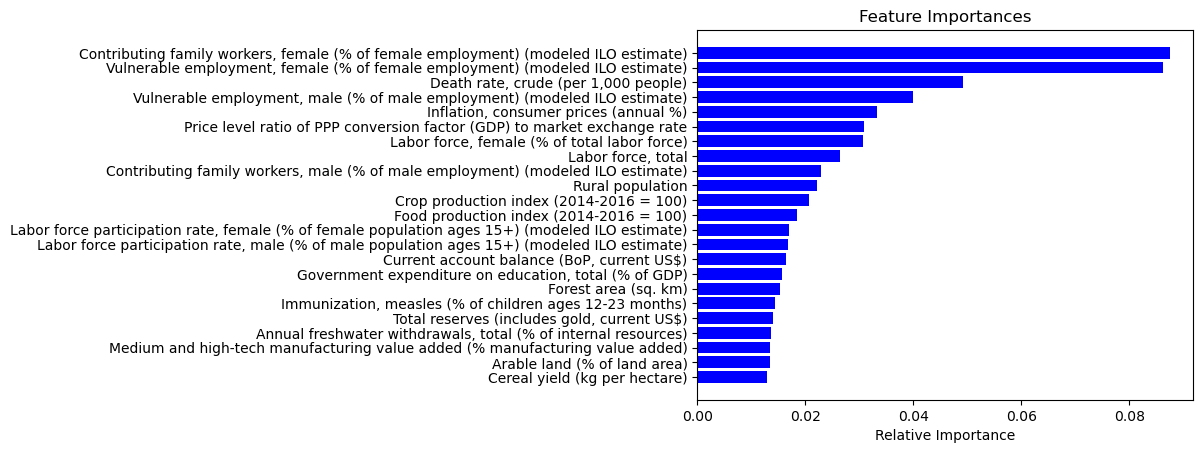

In [22]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(max_depth=10,n_estimators=100,random_state=69)
model.fit(X,y)

n_features = 23      # can be adjusted

# Plot feature importance
features = X.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-n_features:]  # sort top n features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [23]:
important_features = [features[i] for i in indices]
important_features
updated_vars = []
for i in range(-1,-n_features-1,-1):
    updated_vars.append(important_features[i])
print(len(updated_vars))
updated_vars

23


['Contributing family workers, female (% of female employment) (modeled ILO estimate)',
 'Vulnerable employment, female (% of female employment) (modeled ILO estimate)',
 'Death rate, crude (per 1,000 people)',
 'Vulnerable employment, male (% of male employment) (modeled ILO estimate)',
 'Inflation, consumer prices (annual %)',
 'Price level ratio of PPP conversion factor (GDP) to market exchange rate',
 'Labor force, female (% of total labor force)',
 'Labor force, total',
 'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
 'Rural population',
 'Crop production index (2014-2016 = 100)',
 'Food production index (2014-2016 = 100)',
 'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
 'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
 'Current account balance (BoP, current US$)',
 'Government expenditure on education, total (% of GDP)',
 'Forest area (sq. km)',
 

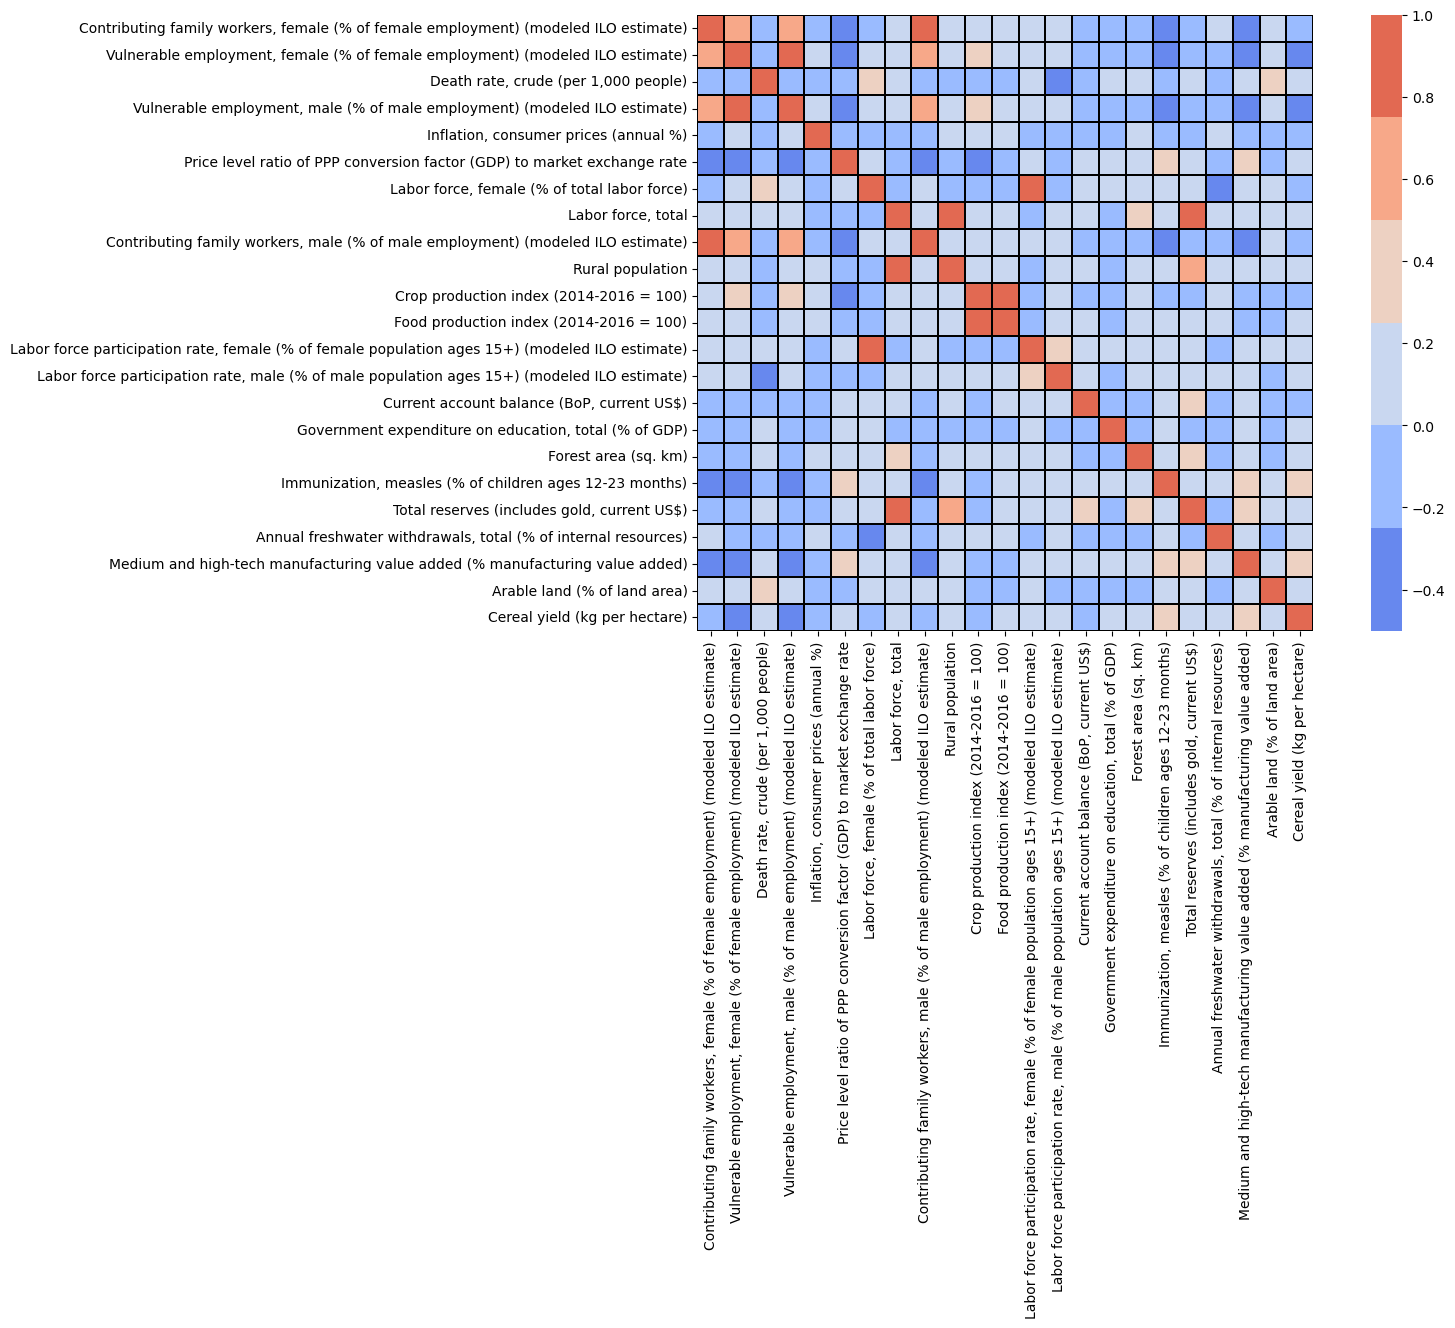

In [24]:
plt.figure(figsize=(15,8))
sns.heatmap(X[updated_vars].corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [25]:
# remove high correlation
high_corr = 'Rural population'
updated_vars.remove(high_corr)
print(len(updated_vars))
updated_vars

22


['Contributing family workers, female (% of female employment) (modeled ILO estimate)',
 'Vulnerable employment, female (% of female employment) (modeled ILO estimate)',
 'Death rate, crude (per 1,000 people)',
 'Vulnerable employment, male (% of male employment) (modeled ILO estimate)',
 'Inflation, consumer prices (annual %)',
 'Price level ratio of PPP conversion factor (GDP) to market exchange rate',
 'Labor force, female (% of total labor force)',
 'Labor force, total',
 'Contributing family workers, male (% of male employment) (modeled ILO estimate)',
 'Crop production index (2014-2016 = 100)',
 'Food production index (2014-2016 = 100)',
 'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)',
 'Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)',
 'Current account balance (BoP, current US$)',
 'Government expenditure on education, total (% of GDP)',
 'Forest area (sq. km)',
 'Immunization, measle

In [26]:
X3 = X[updated_vars]

base_X3_train, base_X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)

X3_train, y3_train = smote(base_X3_train, y3_train)

X3_train, X3_test = scale_standard(X3_train, base_X3_test)

#######################################################
# Construct a model

# selected_k = 5
# from sklearn.neighbors import KNeighborsClassifier
# model = KNeighborsClassifier(n_neighbors = selected_k, metric = 'minkowski', p = 2) # minkowski metric where p = 2 is euclidean distance

# from sklearn.svm import SVC
# model = SVC(kernel = 'rbf', random_state = 0)  

selected_n = 100  # n_estimators  = number of decision trees used in random forest model, default value = 100
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = selected_n, criterion = 'gini', random_state = 0)

model.fit(X3_train, y3_train)
#######################################################

# Use model for predicted responses
y3_pred = model.predict(X3_test)

acc, precision, recall, f1, confusion = evaluate_performance(y3_test, y3_pred)
print(confusion)
print(acc, precision, recall, f1)

[[ 5  0  0  0  1]
 [ 1 11  0  0  4]
 [ 4  2  2  2  1]
 [ 1  1  0  2  0]
 [ 1  0  0  4  2]]
0.5 0.5404761904761906 0.4976731601731602 0.43931623931623925


## Result interpretation

### Interpret the final model

Using 172 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/44 [00:00<?, ?it/s]

/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


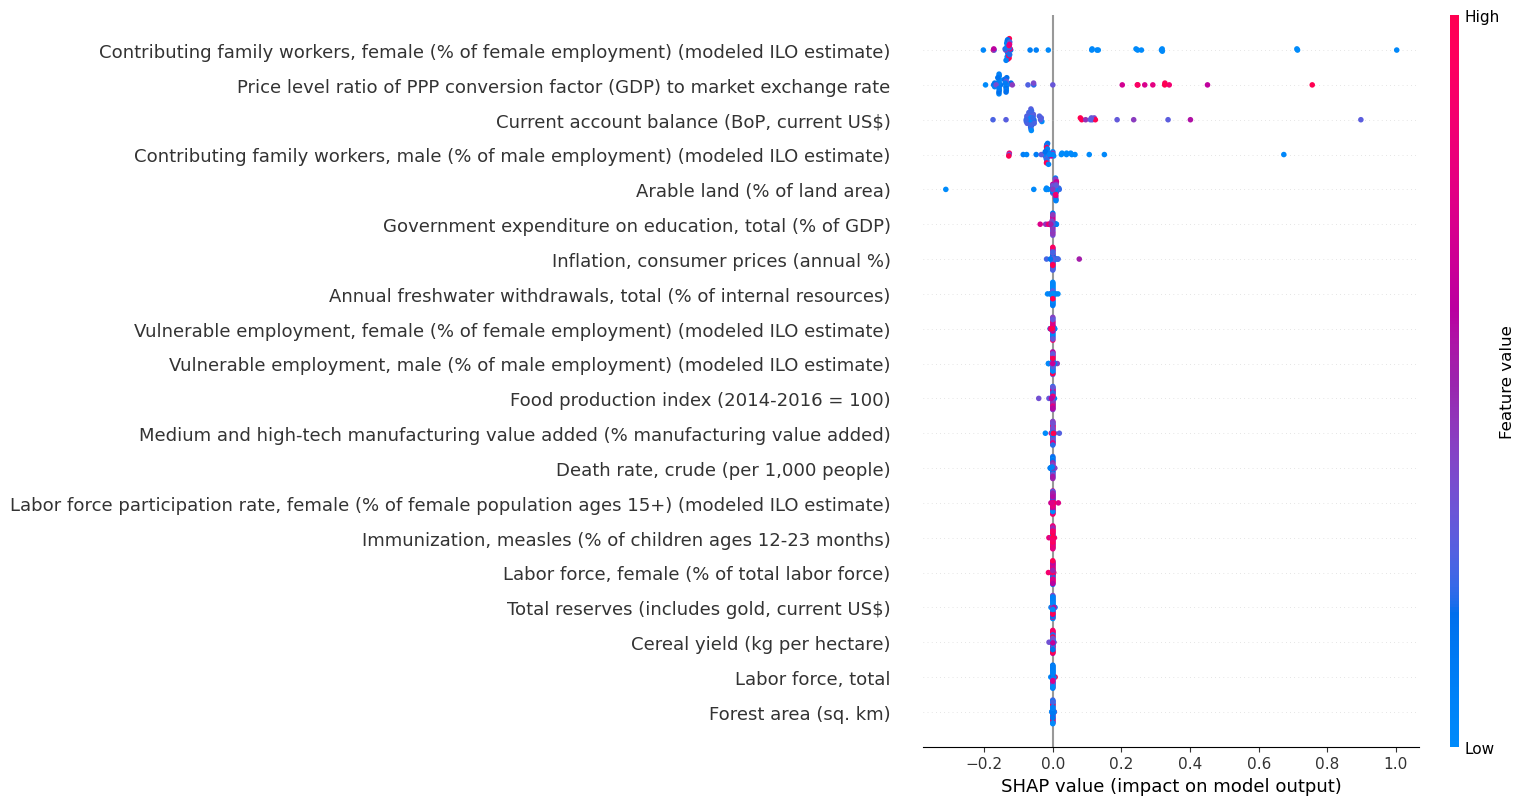

In [27]:
create_shap_values_plot(model, X3, base_X3_train, base_X3_test)

In [28]:
get_permutation_importance(model, X3, X3_test, y3_test)

,feature,importance_mean,importance_std
15,Forest area (sq. km),0.097727,0.047727
5,Price level ratio of PPP conversion factor (GD...,0.095455,0.031818
2,"Death rate, crude (per 1,000 people)",0.090909,0.024896
1,"Vulnerable employment, female (% of female emp...",0.070455,0.027742
7,"Labor force, total",0.061364,0.020455
3,"Vulnerable employment, male (% of male employm...",0.059091,0.025308
14,"Government expenditure on education, total (% ...",0.045455,0.024896
9,Crop production index (2014-2016 = 100),0.043182,0.021441
4,"Inflation, consumer prices (annual %)",0.036364,0.015076
20,Arable land (% of land area),0.036364,0.023177


### Analysis of variance

In [29]:
# Perform Anova test
from statsmodels.formula.api import ols
model = ols('Q("Gender Ratio Class") ~ C(Region)', data=orig_df).fit()

# ANOVA table
import statsmodels.api as sm
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq     df         F    PR(>F)
C(Region)   63.332563   12.0  3.101476  0.000469
Residual   345.440586  203.0       NaN       NaN


In [30]:
orig_df.groupby('Region')['Gender Ratio Class'].mean()

Region
Africa                   2.581818
Australia and Oceanea    3.000000
East Asia                2.857143
Eastern Europe           2.176471
Middle East              3.812500
North America            2.656250
Northern Europe          3.307692
South America            3.000000
South Asia               1.375000
Southeast Asia           2.222222
Thailand                 1.000000
Western Asia             3.875000
Western Europe           3.000000
Name: Gender Ratio Class, dtype: float64

In [31]:
# Prove: Does the mean of Region is the same for all bean Gender Ratio Class?
# H0: m1 = m2 = ... = mJ (means of each cateogory are the same.)
# H1: At least one pair is not the same
# Decision: if p < alpha (significant level) → Reject H0 

# The mean of Region is not the same for all bean Gender Ratio Class because p = 0.0004 < alpha = 0.05 -> Reject H0

### Analysis of Categorical data

In [32]:
contingency_table = pd.crosstab(orig_df['Gender Ratio Class'], orig_df['Region'])
print(contingency_table)

Region              Africa  Australia and Oceanea  East Asia  Eastern Europe  \
Gender Ratio Class                                                             
1.0                     18                      1          1               2   
2.0                     13                     10          3              12   
3.0                      9                      0          1               2   
4.0                      4                      4          0               0   
5.0                     11                      4          2               1   

Region              Middle East  North America  Northern Europe  \
Gender Ratio Class                                                
1.0                           2              2                0   
2.0                           2             20                5   
3.0                           2              3                2   
4.0                           1              1                3   
5.0                           9      

In [33]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 108.06115746471137
p-value: 1.6016993575495517e-06


In [34]:
# Prove: Is bean Gender Ratio Class independent of Region category?
# H0: X and Y are independent 
# H1: X and Y are not independent
# Decision: if p < 0.05 → Reject H0 -> X and Y are not independent -> They are association

# They are associate (not independent) as p = 1.6e-6 < 0.05 -> Reject H0